<a href="https://colab.research.google.com/github/RajeshMameda/geo_data_tool/blob/feature%2Fgeodata-platform-integration/Copy_of_Untitled1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install necessary libraries for climate data processing, analysis, and visualization
!pip install xarray netCDF4 matplotlib pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 67.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 69.3 MB/s eta 0:00:00


In [ ]:
# Import essential libraries:
# xarray for multidimensional array operations (specifically NetCDF files)
# pandas for date/time index manipulation
# matplotlib.pyplot for plotting temperature variations
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Define the path to the input NetCDF climate temperature dataset
file_name = "/content/climate_temp_monthly_1980_1990.nc"

In [ ]:
# Load the monthly temperature NetCDF dataset and display its metadata, coordinates, and variables
ds = xr.open_dataset(file_name)
print(ds)

<xarray.Dataset> Size: 3kB
Dimensions:              (time: 132)
Coordinates:
  * time                 (time) datetime64[ns] 1kB 1980-01-01 ... 1990-12-01
Data variables:
    temperature          (time) float32 528B ...
    baseline_mean        (time) float32 528B ...
    temperature_anomaly  (time) float32 528B ...
Attributes:
    title:                Monthly regional climate temperature, 1980-1990
    source:               Converted from the supplied Excel workbook
    frequency:            monthly
    time_coverage_start:  1980-01-01
    time_coverage_end:    1990-12-01
    baseline_mean_c:      14.04


In [ ]:
# Print key metadata details from the loaded dataset:
# Data variables, coordinates, date range coverage, and total temporal observations
print("data varibles:", list(ds.data_vars))
print("co-oridnates:", list(ds.coords))
print("start date:", ds.time.min().values)
print("end date:", ds.time.max().values)
print("number of timestamps:", ds.sizes["time"])

data varibles: ['temperature', 'baseline_mean', 'temperature_anomaly']
co-oridnates: ['time']
start date: 1980-01-01T00:00:00.000000000
end date: 1990-12-01T00:00:00.000000000
number of timestamps: 132


In [ ]:
# Extract the 'temperature' variable and examine its physical units,
# presence of missing values, and overall minimum and maximum ranges
temp = ds["temperature"]
print(temp)

print("units:", temp.attrs.get("units", "units not specified"))
print("missing values:", int(temp.isnull().sum().values))
print("minimum:", float(temp.min(skipna=True).values))
print("maximum:", float(temp.max(skipna=True).values))

<xarray.DataArray 'temperature' (time: 132)> Size: 528B
array([14.07, 14.48, 14.96, 15.23, 14.83, 14.46, 14.24, 13.62, 13.06, 13.08,
       13.06, 13.43, 14.07, 14.24, 14.64, 14.95, 14.74, 14.58, 13.89, 13.32,
       13.38, 13.  , 13.17, 13.32, 13.98, 14.58, 14.75, 15.12, 14.84, 14.52,
       13.97, 13.84, 13.19, 12.9 , 13.32, 13.38, 14.12, 14.3 , 14.76, 15.12,
       15.07, 14.62, 14.07, 13.54, 13.  , 12.98, 13.15, 13.75, 14.17, 14.36,
       15.03, 15.06, 14.88, 14.71, 14.27, 13.76, 13.13, 13.07, 13.3 , 13.77,
       14.08, 14.62, 14.85, 14.97, 15.14, 14.85, 14.14, 13.8 , 13.34, 13.05,
       13.34, 13.88, 14.17, 14.91, 14.65, 15.3 , 15.06, 14.64, 14.19, 13.38,
       13.28, 13.23, 13.54, 13.6 , 14.09, 14.63, 15.21, 15.26, 15.  , 14.79,
       14.22, 13.86, 13.24, 13.16, 13.29, 13.49, 14.28, 14.78, 15.11, 15.2 ,
       14.89, 14.68, 14.19, 13.62, 13.35, 13.3 , 13.66, 13.77, 14.31, 14.76,
       14.85, 15.27, 15.15, 15.14, 14.24, 13.82, 13.4 , 13.09, 13.58, 13.88,
       14.42, 14.66,

In [ ]:
# Validate temporal completeness of the dataset:
# Compare actual dataset timestamps against an expected continuous monthly sequence
date = pd.DatetimeIndex(ds.time.values)
expected_dates = pd.date_range(
    start=date.min(),
    end=date.max(),
    freq='MS'
)

missing_dates = expected_dates.difference(date)
print("Expected monthly records:", len(expected_dates))
print("Actual records:", len(date))
print("Missing months:", list(missing_dates))

Expected monthly records: 132
Actual records: 132
Missing months: []


In [ ]:
# Check the global attributes of the Dataset as well as the specific metadata attributes of the temperature variable
print(ds.attrs)
print(temp.attrs)

{'title': 'Monthly regional climate temperature, 1980-1990', 'source': 'Converted from the supplied Excel workbook', 'frequency': 'monthly', 'time_coverage_start': '1980-01-01', 'time_coverage_end': '1990-12-01', 'baseline_mean_c': np.float32(14.04)}
{'long_name': 'monthly mean temperature', 'standard_name': 'air_temperature', 'units': 'degree_Celsius'}


In [ ]:
# Identify and list the sorted unique calendar years present in the dataset's timeline
available_years = sorted(
    set(pd.DatetimeIndex(ds.time.values).year)
)
print(available_years)

[1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990]


In [ ]:
# Define the baseline reference period (1981 to 1990) and slice the temperature data to focus on this interval
baseline_start = "1981-01-01"
baseline_end = "1990-12-31"

baseline_temp = temp.sel(
    time = slice(baseline_start, baseline_end)
)
print("Baseline start:", baseline_temp.time.min().values)
print("Baseline end:", baseline_temp.time.max().values)
print("Baseline observations:", baseline_temp.sizes["time"])

Baseline start: 1981-01-01T00:00:00.000000000
Baseline end: 1990-12-01T00:00:00.000000000
Baseline observations: 120


In [ ]:
# Ensure the baseline subset has no missing/null values that could skew average calculations
print("Baseline missing values:",
      int(baseline_temp.isnull().sum().values))

Baseline missing values: 0


In [ ]:
# Calculate climatological monthly means for the baseline period, subtract them from the full time-series
# to compute multi-year seasonal anomalies, and attach metadata attributes describing the baseline
baseline_monthly_mean = baseline_temp.groupby("time.month").mean(dim="time", skipna=True)

temperature_anomaly = (
    temp.groupby("time.month") - baseline_monthly_mean
)

temperature_anomaly.name = "temperature_anomaly"
temperature_anomaly.attrs["description"] = (
    "Monthly temperature anomaly relative to baseline monthly means"
)
temperature_anomaly.attrs["baseline_period"] = (
    f"{baseline_start} to {baseline_end}"
)
temperature_anomaly.attrs["units"] = temp.attrs.get(
    "units", "same as source temperature"
)

print(temperature_anomaly)

<xarray.DataArray 'temperature_anomaly' (time: 132)> Size: 1kB
array([-0.09899902, -0.10400009,  0.03699875,  0.09599972, -0.17200089,
       -0.30600071,  0.1069994 , -0.04600048, -0.21599865, -0.02000046,
       -0.29500008, -0.2349987 , -0.09899902, -0.34399986, -0.28300095,
       -0.18400002, -0.26200104, -0.18600082, -0.24300003, -0.34600067,
        0.10400105, -0.10000038, -0.18500042, -0.34499931, -0.18899918,
       -0.00399971, -0.17300129, -0.01399994, -0.16200066, -0.24600029,
       -0.16300011,  0.17399979, -0.08599949, -0.20000076, -0.0350008 ,
       -0.28499889, -0.04899883, -0.28399944, -0.16300106, -0.01399994,
        0.06799889, -0.14600086, -0.06300068, -0.1260004 , -0.27599907,
       -0.12000084, -0.20500088,  0.08500099,  0.00100136, -0.22399998,
        0.10699844, -0.0739994 , -0.12200069, -0.05600071,  0.13700008,
        0.09399986, -0.14599895, -0.03000069, -0.05500031,  0.10500145,
       -0.08899879,  0.03600025, -0.07300091, -0.16399956,  0.13799953,
 

In [ ]:
# Calculate a single overall mean temperature across the entire baseline time range
# and compute the absolute deviations of the full time series from this overall mean
baseline_mean = baseline_temp.mean(
    dim="time",
    skipna=True
)

temperature_anomaly = temp - baseline_mean
temperature_anomaly.name = "temperature_anomaly"

print("Baseline mean:", baseline_mean.values)
print(temperature_anomaly)

Baseline mean: 14.147750854492188
<xarray.DataArray 'temperature_anomaly' (time: 132)> Size: 1kB
array([-0.07775116,  0.33224869,  0.81224918,  1.08224869,  0.68224907,
        0.31224918,  0.09224892, -0.52775097, -1.08775043, -1.06775093,
       -1.08775043, -0.71775055, -0.07775116,  0.09224892,  0.49224949,
        0.80224895,  0.59224892,  0.43224907, -0.25775051, -0.82775116,
       -0.76775074, -1.14775085, -0.97775078, -0.82775116, -0.16775131,
        0.43224907,  0.60224915,  0.97224903,  0.6922493 ,  0.3722496 ,
       -0.17775059, -0.3077507 , -0.95775127, -1.24775124, -0.82775116,
       -0.76775074, -0.02775097,  0.15224934,  0.61224937,  0.97224903,
        0.92224884,  0.47224903, -0.07775116, -0.60775089, -1.14775085,
       -1.16775131, -0.99775124, -0.39775085,  0.02224922,  0.2122488 ,
        0.88224888,  0.91224957,  0.73224926,  0.56224918,  0.1222496 ,
       -0.38775063, -1.01775074, -1.07775116, -0.84775066, -0.3777504 ,
       -0.06775093,  0.47224903,  0.702

In [ ]:
# Isolate the newly calculated anomalies corresponding to the baseline period
# and verify that their overall mean is centered around zero
baseline_anomalies = temperature_anomaly.sel(
    time=slice(baseline_start, baseline_end)
)

print(
    "Mean baseline anomaly:",
    float(baseline_anomalies.mean(skipna=True).values)
)

Mean baseline anomaly: -8.424123128255208e-07


In [ ]:
# Inspect the first 12 monthly anomalies (representing the year 1980) to understand preliminary variations
print(temperature_anomaly.isel(time=slice(0, 12)).values)

[-0.07775116  0.33224869  0.81224918  1.08224869  0.68224907  0.31224918
  0.09224892 -0.52775097 -1.08775043 -1.06775093 -1.08775043 -0.71775055]


In [ ]:
# Convert the calculated temperature anomaly DataArray to a Dataset structure and save it to a NetCDF file
output = temperature_anomaly.to_dataset()
output.to_netcdf("temperature_anomalies.nc")
print("Saved: temperature_anomalies.nc")

Saved: temperature_anomalies.nc


In [ ]:
# Calculate and print statistical descriptive metrics of the anomalies including min, max, mean, and standard deviation
print("Minimum anomaly:",
      float(temperature_anomaly.min(skipna=True).values))

print("Maximum anomaly:",
      float(temperature_anomaly.max(skipna=True).values))

print("Mean anomaly:",
      float(temperature_anomaly.mean(skipna=True).values))

print("Standard deviation:",
      float(temperature_anomaly.std(skipna=True).values))

Minimum anomaly: -1.247751235961914
Maximum anomaly: 1.2322492599487305
Mean anomaly: -0.009493271509806315
Standard deviation: 0.7202845894676638


In [ ]:
# Analyze anomaly sign distributions by counting how many months had positive, negative, or zero departures from the baseline mean
positive_count = int(
    (temperature_anomaly > 0).sum().values
)

negative_count = int(
    (temperature_anomaly < 0).sum().values
)

zero_count = int(
    (temperature_anomaly == 0).sum().values
)

print("Positive anomalies:", positive_count)
print("Negative anomalies:", negative_count)
print("Zero anomalies:", zero_count)

Positive anomalies: 67
Negative anomalies: 65
Zero anomalies: 0


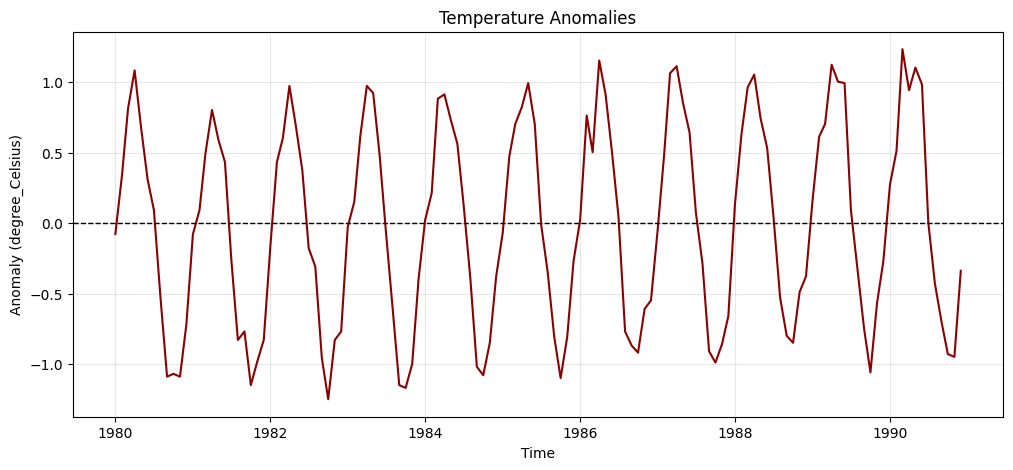

In [ ]:
# Plot the temperature anomalies over the complete period (1980-1990)
# with a zero reference baseline to visually identify historical trends
temperature_anomaly.plot(
    figsize=(12, 5),
    color="darkred"
)

plt.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1
)

plt.title("Temperature Anomalies")
plt.ylabel(
    f"Anomaly ({temperature_anomaly.attrs.get('units', '')})"
)
plt.xlabel("Time")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# Print the core dimensions of the final temperature anomaly variable to verify its indexing alignment
print("Anomaly dimensions:", temperature_anomaly.dims)

Anomaly dimensions: ('time',)
